In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("loan defaulter.csv")

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61565 entries, 0 to 61564
Data columns (total 35 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            61565 non-null  int64  
 1   Loan Amount                   61565 non-null  int64  
 2   Funded Amount                 61565 non-null  int64  
 3   Funded Amount Investor        61565 non-null  float64
 4   Term                          61565 non-null  int64  
 5   Batch Enrolled                61565 non-null  object 
 6   Interest Rate                 61565 non-null  float64
 7   Grade                         61565 non-null  object 
 8   Sub Grade                     61565 non-null  object 
 9   Employment Duration           61565 non-null  object 
 10  Home Ownership                61565 non-null  float64
 11  Verification Status           61565 non-null  object 
 12  Payment Plan                  61565 non-null  object 
 13  L

In [7]:
df.ID.value_counts()

,count
ID,
5644189,1
65087372,1
1450153,1
1969101,1
6651430,1
...,...
44295986,1
48621970,1
9813088,1


# Q20 Select numeric columns and compute correlation with 'Funded Amount Investor'

In [10]:
numeric_df = df.select_dtypes(include=["number"])
correlations = (
    numeric_df.corr()["Funded Amount Investor"]
    .sort_values(ascending=False)
)

print("Top factors correlated with Funded Amount Investor:")
print(correlations)

Top factors correlated with Funded Amount Investor:
Funded Amount Investor          1.000000
Funded Amount                   0.009742
Public Record                   0.006640
Total Collection Amount         0.005655
Total Revolving Credit Limit    0.005138
ID                              0.004670
Total Accounts                  0.004056
Loan Amount                     0.003222
Total Current Balance           0.002844
Last week Pay                   0.002792
Delinquency - two years         0.002274
Home Ownership                  0.001818
Debit to Income                 0.001379
Recoveries                      0.001200
Total Received Interest         0.000341
Collection 12 months Medical    0.000279
Total Received Late Fee         0.000088
Loan Status                    -0.000531
Inquires - six months          -0.001133
Interest Rate                  -0.001465
Revolving Utilities            -0.001793
Open Account                   -0.006786
Collection Recovery Fee        -0.007053
Revol

# Q 22 Analyze if there is any anomaly in interest rates for different employment durations

=== Interest Rate Statistics by Employment Duration ===
                     Count   Mean  Median   Std   Min    Max
Employment Duration                                         
MORTGAGE             33259  11.79   11.30  3.70  5.32  27.18
OWN                   6334  11.95   11.50  3.84  5.33  26.30
RENT                 21972  11.91   11.46  3.70  5.32  26.93

Total Statistical Anomalies (|Z| > 3): 321
     Employment Duration  Interest Rate Grade  IR_ZScore
228                 RENT      23.107420     B   3.028752
238             MORTGAGE      24.670390     C   3.449230
329             MORTGAGE      24.078437     E   3.289980
357             MORTGAGE      23.947542     A   3.254766
899                 RENT      23.035149     C   3.009310
1013                RENT      23.365227     D   3.098109
1298            MORTGAGE      23.349153     B   3.093785
1319            MORTGAGE      26.920449     F   4.054551
1360            MORTGAGE      23.349293     C   3.093822
1497            MORTGAGE 

/tmp/ipykernel_1333/2027397983.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


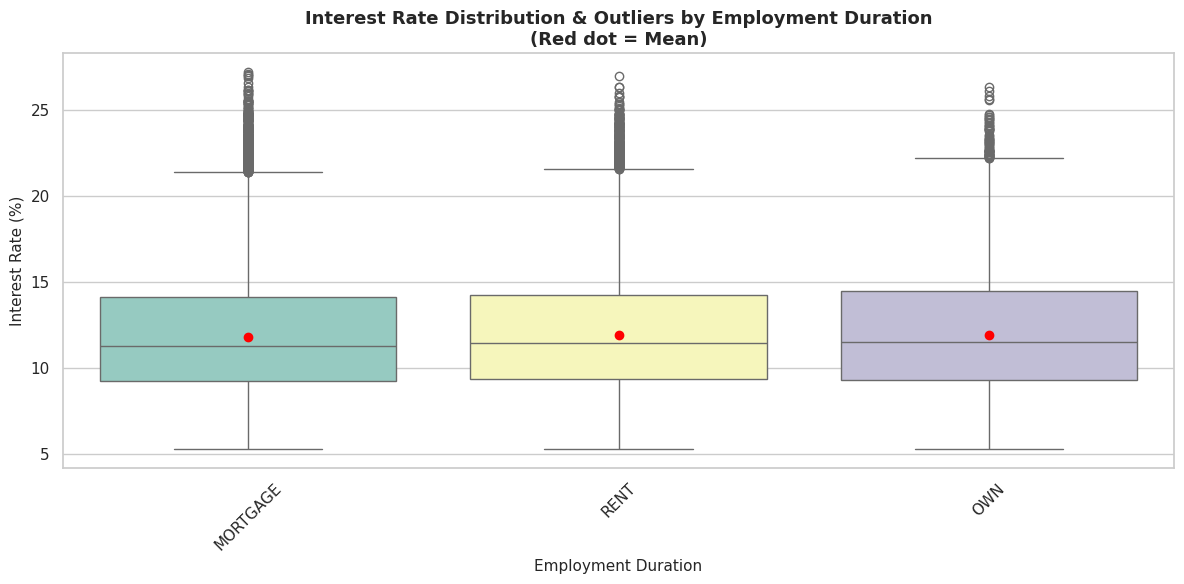

In [16]:



# Clean 'Interest Rate' if stored as text/percentage
if df["Interest Rate"].dtype == "object":
    df["Interest Rate"] = (
        df["Interest Rate"].astype(str).str.rstrip("%").astype(float)
    )

# 1. Group Statistics: Mean, Median, Min, Max, Std
emp_ir_stats = df.groupby("Employment Duration")["Interest Rate"].agg(
    Count="count",
    Mean="mean",
    Median="median",
    Std="std",
    Min="min",
    Max="max",
)

print("=== Interest Rate Statistics by Employment Duration ===")
print(emp_ir_stats.round(2))

# 2. Identify Outliers using Z-Score (|Z| > 3)
df["IR_ZScore"] = (
    df["Interest Rate"] - df["Interest Rate"].mean()
) / df["Interest Rate"].std()
anomalies = df[df["IR_ZScore"].abs() > 3][
    ["Employment Duration", "Interest Rate", "Grade", "IR_ZScore"]
]

print(f"\nTotal Statistical Anomalies (|Z| > 3): {len(anomalies)}")
print(anomalies.head(10))

# 3. Visual Analysis: Boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df,
    x="Employment Duration",
    y="Interest Rate",
    palette="Set3",
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "red",
        "markeredgecolor": "red",
    },
)

plt.title(
    "Interest Rate Distribution & Outliers by Employment Duration\n(Red dot = Mean)",
    fontsize=13,
    fontweight="bold",
)
plt.xlabel("Employment Duration", fontsize=11)
plt.ylabel("Interest Rate (%)", fontsize=11)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Q 23 How does the ratio of funded amount to loan amount vary across different loan statuses?

In [17]:


df["Funding_Ratio"] = df["Funded Amount"] / df["Loan Amount"]

funding_summary = df.groupby("Loan Status")["Funding_Ratio"].agg(
    Mean="mean",
    Median="median",
    Min="min",
    Std="std",
    Count="count",
)
print("=== Funding Ratio Summary by Loan Status ===")
print((funding_summary * 100).round(2).astype(str) + "%")

=== Funding Ratio Summary by Loan Status ===
                Mean  Median    Min      Std     Count
Loan Status                                           
0.0          136.47%  91.94%  3.08%  155.56%  5586600%
1.0          140.39%  93.56%  7.93%  160.47%   569800%
